In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from AttackInfo import attack_info, Sensors, stage_map
import warnings
warnings.filterwarnings('ignore')

In [ ]:
'''
Label vs Detailed Label

- Label(Binary Label): 0/Normal, 1/Attack
- Detailed Label:(Multi-label): Normal, Attack1, ..., Attack41

Label of data type is integer.
Detailed Label of data type is string.
'''


In [12]:
df_normal = pd.read_parquet('../../Dataset/SWaT_Dataset_Normal_v1.parquet')
df_attack  = pd.read_parquet('../../Dataset/SWaT_Dataset_Attack_v1.parquet')

In [18]:
# 11.3 滑動窗口注意事項：Attack_v1 的時間斷點
df_attack = df_attack.drop(['P603'], axis=1)

ts_attack_sorted = df_attack['Timestamp'].sort_values().reset_index(drop=True)
diff_attack = ts_attack_sorted.diff().iloc[1:]
gaps_attack = diff_attack[diff_attack > pd.Timedelta(seconds=1)]

if gaps_attack.empty:
    print("✅ Attack_v1 時間完全連續，無需特別處理")
else:
    print(f"⚠️ Attack_v1 發現 {len(gaps_attack)} 處時間斷點：")
    for idx in gaps_attack.index:
        t_before = ts_attack_sorted[idx-1]
        t_after  = ts_attack_sorted[idx]
        gap_s    = gaps_attack[idx].total_seconds()
        labels_before = df_attack[df_attack['Timestamp'] == t_before]['Detailed_Label'].values
        labels_after  = df_attack[df_attack['Timestamp'] == t_after]['Detailed_Label'].values
        print(f"   斷點前: {t_before} ({labels_before})")
        print(f"   斷點後: {t_after} ({labels_after})")
        print(f"   間隔: {gap_s:.0f} 秒 ({gap_s/60:.1f} 分鐘)")
        print(f"   → 使用滑動窗口時，不可跨越此斷點！")
        print()

⚠️ Attack_v1 發現 1 處時間斷點：
   斷點前: 2015-12-31 21:00:36 (['Normal'])
   斷點後: 2015-12-31 21:01:58 (['Normal'])
   間隔: 82 秒 (1.4 分鐘)
   → 使用滑動窗口時，不可跨越此斷點！



In [63]:
# 4.1 Attack_v1 各攻擊標籤的時間範圍與筆數
print("=== Attack_v1 各 Detailed_Label 時間區間 ===\n")
label_ranges = []
for label in sorted(df_attack['Detailed_Label'].unique()):
    sub = df_attack[df_attack['Detailed_Label'] == label]
    duration_s = (sub['Timestamp'].max() - sub['Timestamp'].min()).total_seconds()
    atk_id = None
    if label.startswith('Attack'):
        try:
            atk_id = int(label.replace('Attack', ''))
        except:
            pass
    label_ranges.append({
        'Detailed_Label': label,
        'Attack#': atk_id,
        'Start': sub['Timestamp'].min(),
        'End': sub['Timestamp'].max(),
        'Rows': len(sub),
        'Duration(s)': int(duration_s + 1),
        'Category': attack_info[atk_id]['cat'] if atk_id and atk_id in attack_info else '—',
        'Type': attack_info[atk_id]['type'] if atk_id and atk_id in attack_info else '—',
        'Actual Change': attack_info[atk_id]['actual_change'] if atk_id and atk_id in attack_info else '—',
    })

range_df = pd.DataFrame(label_ranges)
display(range_df.set_index('Detailed_Label'))

=== Attack_v1 各 Detailed_Label 時間區間 ===



,Attack#,Start,End,Rows,Duration(s),Category,Type,Actual Change
Detailed_Label,,,,,,,,
Attack1,1.0,2015-12-28 10:29:14,2015-12-28 10:44:53,940,940,SSSP,actuator,True
Attack10,10.0,2015-12-28 14:16:20,2015-12-28 14:18:59,160,160,SSSP,sensor,False
Attack11,11.0,2015-12-28 14:19:00,2015-12-28 14:28:20,561,561,SSSP,sensor,False
Attack13,13.0,2015-12-29 11:11:25,2015-12-29 11:15:17,233,233,SSSP,actuator,True
Attack14,14.0,2015-12-29 11:35:40,2015-12-29 11:42:50,431,431,SSSP,actuator,True
Attack16,16.0,2015-12-29 11:57:25,2015-12-29 12:02:00,276,276,SSSP,sensor,False
Attack17,17.0,2015-12-29 14:38:12,2015-12-29 14:50:08,717,717,SSSP,actuator,True
Attack19,19.0,2015-12-29 18:10:43,2015-12-29 18:15:01,259,259,SSSP,sensor,False
Attack2,2.0,2015-12-28 10:51:08,2015-12-28 10:58:30,443,443,SSSP,actuator,True


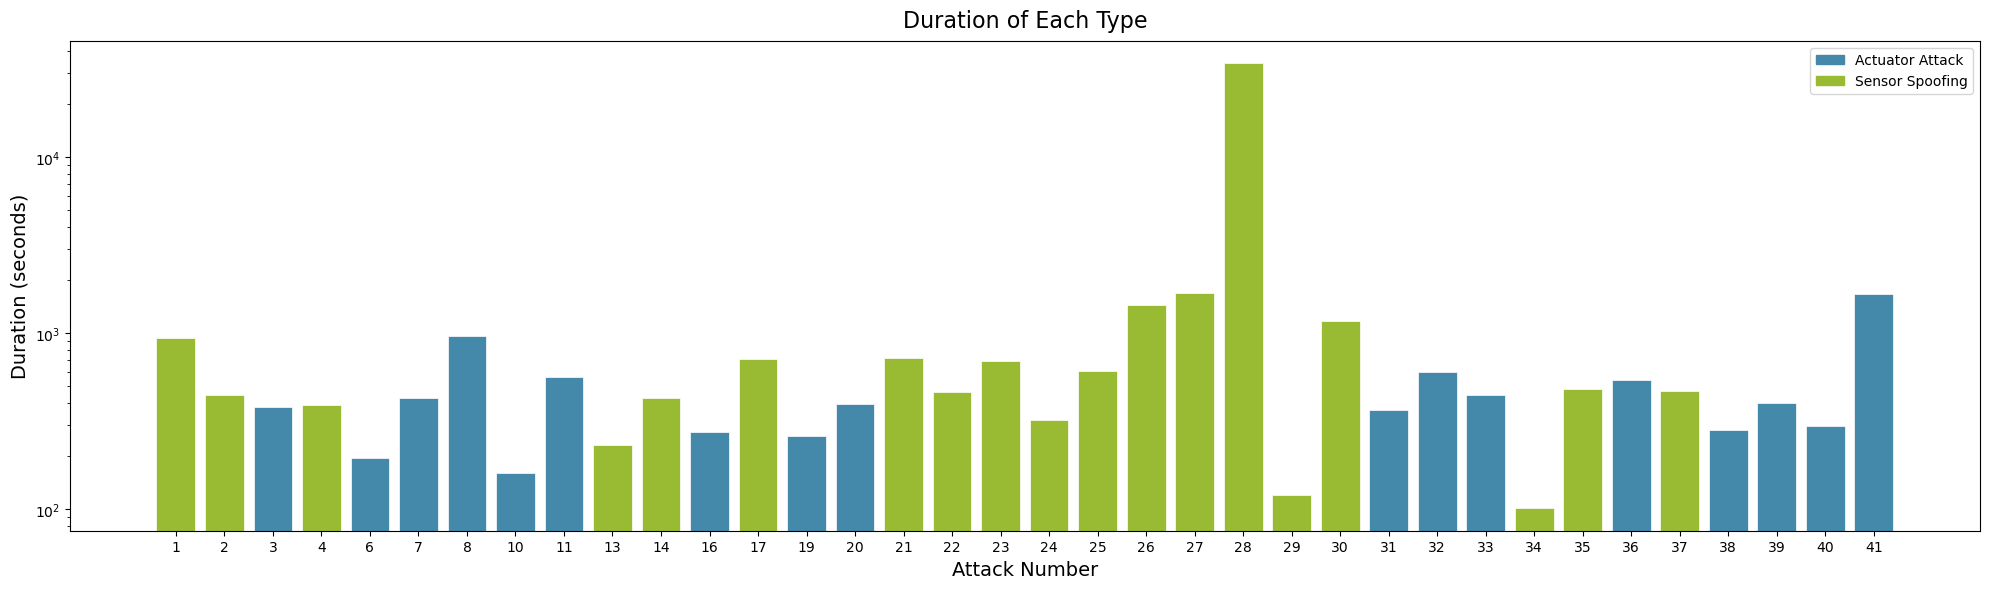


攻擊時間視窗總筆數   : 53,885
正常時間視窗總筆數   : 396,034
攻擊比例           : 11.98%


In [64]:
# 攻擊持續時間分佈
atk_only = range_df[range_df['Attack#'].notna()].copy()
atk_only['Attack#'] = atk_only['Attack#'].astype(int)
atk_only = atk_only.sort_values('Attack#')

# 將 Attack# 轉為字串，避免 X 軸出現數值間隔的空隙
atk_only['Attack_Str'] = atk_only['Attack#'].astype(str)

fig, ax = plt.subplots(figsize=(20, 6))

# 定義顏色
color_actuator = '#4488AA' # 藍色
color_sensor = '#99BB33'   # 綠色 (根據您先前的邏輯)

colors = [color_actuator if not r['Actual Change'] == True else color_sensor 
          for _, r in atk_only.iterrows()]

# 繪製柱狀圖
bars = ax.bar(atk_only['Attack_Str'], atk_only['Duration(s)'], color=colors, edgecolor='white', linewidth=0.5)

# 設定標籤與標題
ax.set_xlabel('Attack Number', fontsize=14,)
ax.set_ylabel('Duration (seconds)', fontsize=14, )
ax.set_title('Duration of Each Type', fontsize=16, pad=10)
ax.set_yscale('log')

# 建立圖例 (Legend)
# 根據代碼邏輯：Actual Change 為 False 是 Actuator Attack，True 為 Sensor Spoof
blue_patch = mpatches.Patch(color=color_actuator, label='Actuator Attack')
green_patch = mpatches.Patch(color=color_sensor, label='Sensor Spoofing')
ax.legend(handles=[blue_patch, green_patch], loc='upper right')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 輸出統計資訊
print(f"\n攻擊時間視窗總筆數   : {df_attack[df_attack['Label'] == 1].shape[0]:,}")
print(f"正常時間視窗總筆數   : {df_attack[df_attack['Label'] == 0].shape[0]:,}")
print(f"攻擊比例           : {df_attack[df_attack['Label'] == 1].shape[0] / len(df_attack) * 100:.2f}%")

In [ ]:
'''
 No Physical Impact 攻擊驗證
比較各 NPI 攻擊時間視窗內的感測器均值，與 Normal 均值的差距

Attack5  (2015-12-28 11:58:20 ~ 2015-12-28 12:00:54, 155 筆)
     LIT101    : attack_mean=  506.9587, normal_mean=  587.5328, z-score=0.66
     LIT301    : attack_mean=  856.2137, normal_mean=  899.8929, z-score=0.47
     LIT401    : attack_mean=  898.3250, normal_mean=  882.8369, z-score=0.18
     FIT101    : attack_mean=    2.5386, normal_mean=    1.8505, z-score=0.61
     FIT401    : attack_mean=    1.7216, normal_mean=    1.7047, z-score=0.18
  ⚠️ AIT202    : attack_mean=    8.0305, normal_mean=    8.3882, z-score=3.96
     DPIT301   : attack_mean=   19.7254, normal_mean=   16.6047, z-score=0.46

Attack9  (2015-12-28 14:15:00 ~ 2015-12-28 14:16:19, 80 筆)
     LIT101    : attack_mean=  527.7210, normal_mean=  587.5328, z-score=0.49
     LIT301    : attack_mean=  958.7571, normal_mean=  899.8929, z-score=0.63
     LIT401    : attack_mean=  747.8515, normal_mean=  882.8369, z-score=1.54
     FIT101    : attack_mean=    2.5485, normal_mean=    1.8505, z-score=0.62
     FIT401    : attack_mean=    1.4814, normal_mean=    1.7047, z-score=2.37
     AIT202    : attack_mean=    8.3658, normal_mean=    8.3882, z-score=0.25
     DPIT301   : attack_mean=   19.5087, normal_mean=   16.6047, z-score=0.43

Attack12  (2015-12-29 11:10:40 ~ 2015-12-29 11:11:24, 45 筆)
     LIT101    : attack_mean=  504.7041, normal_mean=  587.5328, z-score=0.68
     LIT301    : attack_mean=  909.7739, normal_mean=  899.8929, z-score=0.11
     LIT401    : attack_mean=  870.0564, normal_mean=  882.8369, z-score=0.15
     FIT101    : attack_mean=    2.5548, normal_mean=    1.8505, z-score=0.62
     FIT401    : attack_mean=    1.7100, normal_mean=    1.7047, z-score=0.06
     AIT202    : attack_mean=    8.3943, normal_mean=    8.3882, z-score=0.07
     DPIT301   : attack_mean=   14.2888, normal_mean=   16.6047, z-score=0.34

Attack15  (2015-12-29 11:52:01 ~ 2015-12-29 11:57:24, 324 筆)
     LIT101    : attack_mean=  812.7261, normal_mean=  587.5328, z-score=1.85
     LIT301    : attack_mean=  896.5328, normal_mean=  899.8929, z-score=0.04
     LIT401    : attack_mean=  794.2943, normal_mean=  882.8369, z-score=1.01
     FIT101    : attack_mean=    0.0000, normal_mean=    1.8505, z-score=1.63
     FIT401    : attack_mean=    1.7094, normal_mean=    1.7047, z-score=0.05
     AIT202    : attack_mean=    8.4850, normal_mean=    8.3882, z-score=1.07
     DPIT301   : attack_mean=   19.9347, normal_mean=   16.6047, z-score=0.49

Attack18  (2015-12-29 18:08:55 ~ 2015-12-29 18:10:42, 108 筆)
     LIT101    : attack_mean=  501.1945, normal_mean=  587.5328, z-score=0.71
     LIT301    : attack_mean=  853.0984, normal_mean=  899.8929, z-score=0.50
     LIT401    : attack_mean=  907.8869, normal_mean=  882.8369, z-score=0.29
     FIT101    : attack_mean=    2.5496, normal_mean=    1.8505, z-score=0.62
     FIT401    : attack_mean=    1.7250, normal_mean=    1.7047, z-score=0.22
     AIT202    : attack_mean=    8.3886, normal_mean=    8.3882, z-score=0.00
     DPIT301   : attack_mean=   19.8247, normal_mean=   16.6047, z-score=0.48
'''

In [56]:
# 5.2 感測器欺騙攻擊（Actual Change = No）— 攻擊點 vs 非攻擊點
# 以 Attack3 (Spoof LIT-101) 為例
sensor_spoof_examples = {
    3:  ('LIT101',  ['FIT101', 'MV101', 'P101']),
    7:  ('LIT301',  ['FIT301', 'MV302', 'P301']),
    8:  ('DPIT301', ['FIT301', 'LIT301', 'P302']),
    36: ('LIT101',  ['FIT101', 'P101', 'MV101']),
    40: ('FIT401',  ['LIT401', 'UV401', 'P401']),
}

for atk_id, (spoofed, related) in sensor_spoof_examples.items():
    label_str = f'Attack{atk_id}'
    sub = df_attack[df_attack['Detailed_Label'] == label_str]
    if sub.empty:
        continue

    # 取攻擊前 5 分鐘作為 local baseline
    t_start = sub['Timestamp'].min()
    baseline = df_attack[(df_attack['Timestamp'] >= t_start - pd.Timedelta(minutes=5)) &
                         (df_attack['Timestamp'] <  t_start)]

    print(f"Attack{atk_id} — 欺騙 {spoofed}")
    print(f"  時間：{t_start.strftime('%m/%d %H:%M:%S')} ~ {sub['Timestamp'].max().strftime('%H:%M:%S')} ({len(sub)} 筆)")
    if not baseline.empty:
        print(f"  {spoofed:10s}: 攻擊前均值={baseline[spoofed].mean():.4f}, 攻擊中均值={sub[spoofed].mean():.4f}  ← 應有明顯變化")
        for col in related:
            if col in df_attack.columns:
                b_val = baseline[col].mean()
                a_val = sub[col].mean()
                print(f"  {col:10s}: 攻擊前={b_val:.4f}, 攻擊中={a_val:.4f}")
    print()

Attack3 — 欺騙 LIT101
  時間：12/28 11:22:00 ~ 11:28:22 (383 筆)
  LIT101    : 攻擊前均值=548.7231, 攻擊中均值=759.6077  ← 應有明顯變化
  FIT101    : 攻擊前=2.5459, 攻擊中=1.5811
  MV101     : 攻擊前=2.0000, 攻擊中=1.5666
  P101      : 攻擊前=1.1933, 攻擊中=1.0000

Attack7 — 欺騙 LIT301
  時間：12/28 12:08:25 ~ 12:15:33 (429 筆)
  LIT301    : 攻擊前均值=920.2346, 攻擊中均值=1177.4048  ← 應有明顯變化
  FIT301    : 攻擊前=1.4746, 攻擊中=2.2130
  MV302     : 攻擊前=1.4467, 攻擊中=2.0000
  P301      : 攻擊前=1.0000, 攻擊中=1.0000

Attack8 — 欺騙 DPIT301
  時間：12/28 13:10:10 ~ 13:26:13 (964 筆)
  DPIT301   : 攻擊前均值=21.6864, 攻擊中均值=44.4530  ← 應有明顯變化
  FIT301    : 攻擊前=2.0832, 攻擊中=0.9018
  LIT301    : 攻擊前=829.9154, 攻擊中=948.8551
  P302      : 攻擊前=1.9167, 攻擊中=1.3195

Attack36 — 欺騙 LIT101
  時間：01/01 22:16:01 ~ 22:25:00 (540 筆)
  LIT101    : 攻擊前均值=542.0003, 攻擊中均值=289.1921  ← 應有明顯變化
  FIT101    : 攻擊前=2.5436, 攻擊中=2.5444
  P101      : 攻擊前=1.4967, 攻擊中=1.0000
  MV101     : 攻擊前=2.0000, 攻擊中=2.0000

Attack40 — 欺騙 FIT401
  時間：01/02 11:51:42 ~ 11:56:38 (297 筆)
  FIT401    : 攻擊前均值=0.6494, 攻擊中

In [65]:
# 5.3 實際變化率（Label=1 中真正異常的比例估計）
# 對每個攻擊，計算攻擊點感測器與 Normal 基準的 z-score，看有多少筆真正超出 3σ

normal_mean = df_normal[Sensors].mean()
normal_std  = df_normal[Sensors].std()

anomaly_rows_per_attack = []
for label_str in df_attack['Detailed_Label'].unique():
    if label_str == 'Normal':
        continue
    atk_id_str = label_str.replace('Attack', '')
    try:
        atk_id = int(atk_id_str)
    except:
        continue
    if atk_id not in attack_info:
        continue

    sub = df_attack[df_attack['Detailed_Label'] == label_str]
    # 只計算有感測器攻擊點的攻擊
    atk_points = [p for p in attack_info[atk_id]['point'] if p in Sensors]
    if not atk_points:
        anomaly_rate = 0.0
    else:
        # 計算攻擊點感測器的 z-score
        z_scores = (sub[atk_points] - normal_mean[atk_points]) / (normal_std[atk_points] + 1e-9)
        anomaly_rate = (z_scores.abs() > 3).any(axis=1).mean()

    anomaly_rows_per_attack.append({
        'Attack': label_str,
        'Rows': len(sub),
        'Category': attack_info[atk_id]['cat'],
        'Type': attack_info[atk_id]['type'],
        'Actual Change': attack_info[atk_id]['actual_change'],
        'Physical Impact': attack_info[atk_id]['impact'],
        'Sensor Attack Points': ', '.join(atk_points) if atk_points else '—',
        'Anomaly Rate (3σ)': f'{anomaly_rate*100:.1f}%',
    })

anomaly_df = pd.DataFrame(anomaly_rows_per_attack).sort_values('Attack')
display(anomaly_df.set_index('Attack'))
print()
print("結論：Anomaly Rate = 0% 代表該攻擊時間視窗內，感測器攻擊點數值與 Normal 無統計顯著差異")
print("(NPI 攻擊、無感測器攻擊點的純執行器攻擊 均會顯示 0%)")

,Rows,Category,Type,Actual Change,Physical Impact,Sensor Attack Points,Anomaly Rate (3σ)
Attack,,,,,,,
Attack1,940,SSSP,actuator,True,True,—,0.0%
Attack10,160,SSSP,sensor,False,True,FIT401,100.0%
Attack11,561,SSSP,sensor,False,True,FIT401,98.0%
Attack13,233,SSSP,actuator,True,True,—,0.0%
Attack14,431,SSSP,actuator,True,True,—,0.0%
Attack16,276,SSSP,sensor,False,True,LIT301,15.9%
Attack17,717,SSSP,actuator,True,True,—,0.0%
Attack19,259,SSSP,sensor,False,False,AIT504,0.0%
Attack2,443,SSSP,actuator,True,True,—,0.0%



結論：Anomaly Rate = 0% 代表該攻擊時間視窗內，感測器攻擊點數值與 Normal 無統計顯著差異
(NPI 攻擊、無感測器攻擊點的純執行器攻擊 均會顯示 0%)


/Users/cacslab/miniconda3/envs/pytorch/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/cacslab/miniconda3/envs/pytorch/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/cacslab/miniconda3/envs/pytorch/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/cacslab/miniconda3/envs/pytorch/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 23565 (\N{CJK UNIFIED IDEOGRAPH-5C0D}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/cacslab/miniconda3/envs/pytorch/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fi

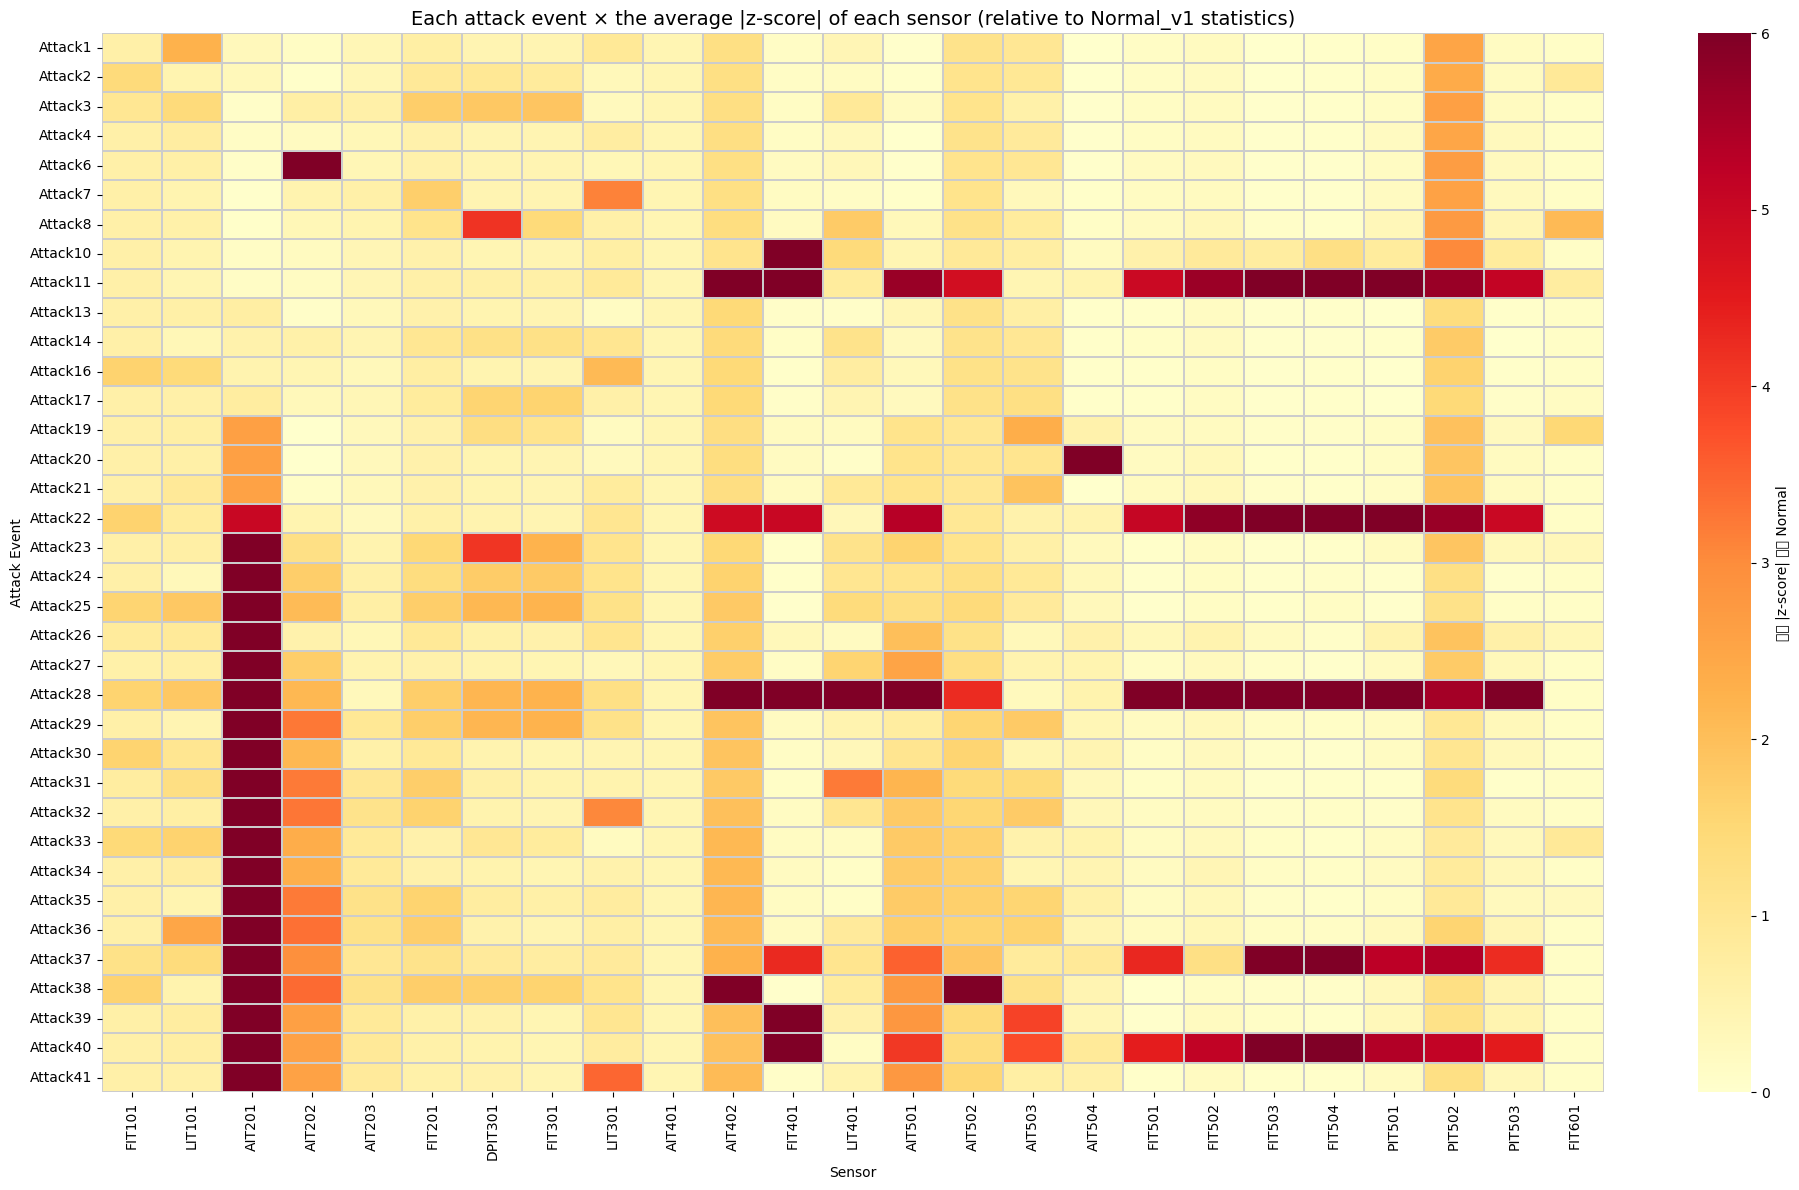

z-score > 3 表示該感測器在攻擊期間的均值超出 Normal ±3σ 範圍


In [4]:
# 10.1 每場攻擊 × 每個感測器的平均 |z-score|
normal_mean = df_normal[Sensors].mean()
normal_std  = df_normal[Sensors].std()

z_matrix = {}
attack_labels_sorted = [f'Attack{i}' for i in range(1, 42)]

for label_str in attack_labels_sorted:
    sub = df_attack[df_attack['Detailed_Label'] == label_str]
    if sub.empty:
        continue
    atk_id = int(label_str.replace('Attack', ''))
    z_scores = ((sub[Sensors] - normal_mean) / (normal_std + 1e-9)).abs().mean()
    z_matrix[label_str] = z_scores

z_df = pd.DataFrame(z_matrix).T  # shape: (attacks, sensors)
z_df.index.name = 'Attack'

fig, ax = plt.subplots(figsize=(20, 12))
sns.heatmap(z_df, ax=ax, cmap='YlOrRd', vmin=0, vmax=6,
            linewidths=0.2, linecolor='#cccccc',
            cbar_kws={'label': '平均 |z-score| 相對 Normal'})
ax.set_title('Each attack event × the average |z-score| of each sensor (relative to Normal_v1 statistics)', fontsize=14)
ax.set_xlabel('Sensor')
ax.set_ylabel('Attack Event')
plt.tight_layout()
plt.show()

print("z-score > 3 表示該感測器在攻擊期間的均值超出 Normal ±3σ 範圍")

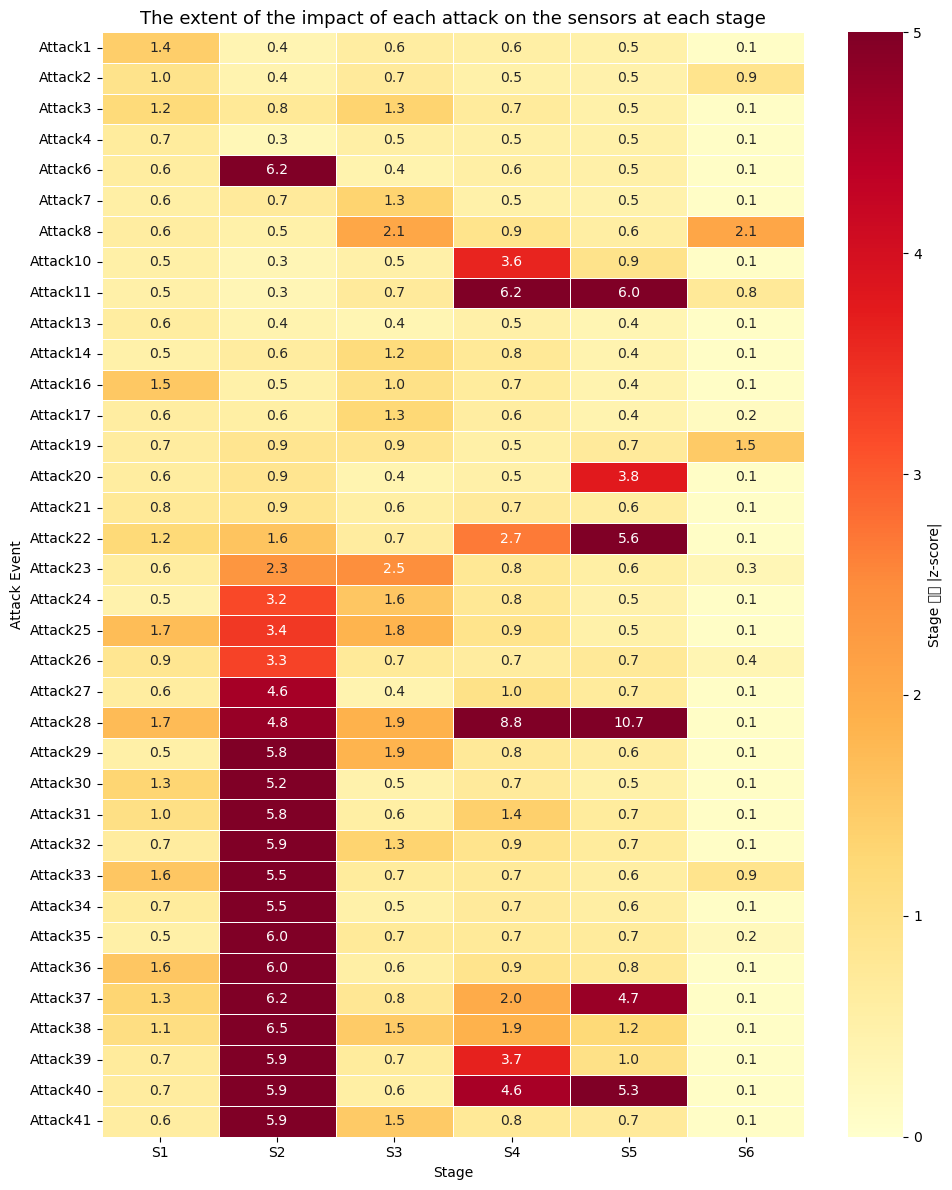

In [7]:
# 10.2 各攻擊對各 Stage 的影響程度（按 Stage 聚合 z-score）
stage_z = {}
for label_str in attack_labels_sorted:
    if label_str not in z_matrix:
        continue
    stage_z_row = {}
    for stage, info in stage_map.items():
        s_cols = [c for c in info['sensors'] if c in z_df.columns]
        if s_cols:
            stage_z_row[f'S{stage}'] = z_df.loc[label_str, s_cols].mean()
        else:
            stage_z_row[f'S{stage}'] = 0.0
    stage_z[label_str] = stage_z_row

stage_z_df = pd.DataFrame(stage_z).T

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(stage_z_df, ax=ax, cmap='YlOrRd', vmin=0, vmax=5,
            annot=True, fmt='.1f', linewidths=0.5,
            cbar_kws={'label': 'Stage 平均 |z-score|'})
ax.set_title('The extent of the impact of each attack on the sensors at each stage', fontsize=13)
ax.set_xlabel('Stage')
ax.set_ylabel('Attack Event')
plt.tight_layout()
plt.show()

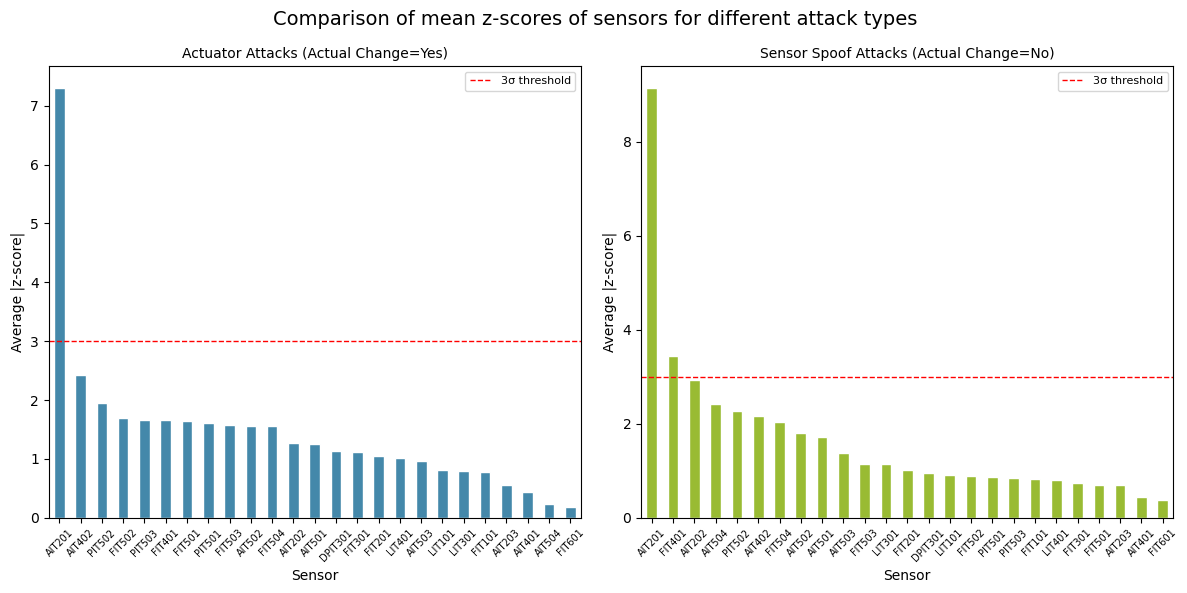

In [9]:
# 10.3 攻擊類型比較：Actuator vs Sensor Spoof vs NPI
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
type_map = {
    'actuator': ('Actuator Attacks (Actual Change=Yes)', '#4488AA'),
    'sensor':   ('Sensor Spoof Attacks (Actual Change=No)', '#99BB33'),
}
color_actuator = '#4488AA' # 藍色
color_sensor = '#99BB33' 

for ax, (atype, (title, color)) in zip(axes, type_map.items()):
    if atype == 'actuator':
        ids = [k for k, v in attack_info.items() if v['type'] == 'actuator']
    else:
        ids = [k for k, v in attack_info.items() if v['type'] == 'sensor']

    labels = [f'Attack{i}' for i in ids if f'Attack{i}' in z_matrix]
    if not labels:
        ax.set_visible(False)
        continue

    z_sub = z_df.loc[labels].mean()
    z_sub.sort_values(ascending=False).plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Sensor')
    ax.set_ylabel('Average |z-score|')
    ax.axhline(3, color='red', ls='--', lw=1, label='3σ threshold')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('Comparison of mean z-scores of sensors for different attack types', fontsize=14)
plt.tight_layout()
plt.show()

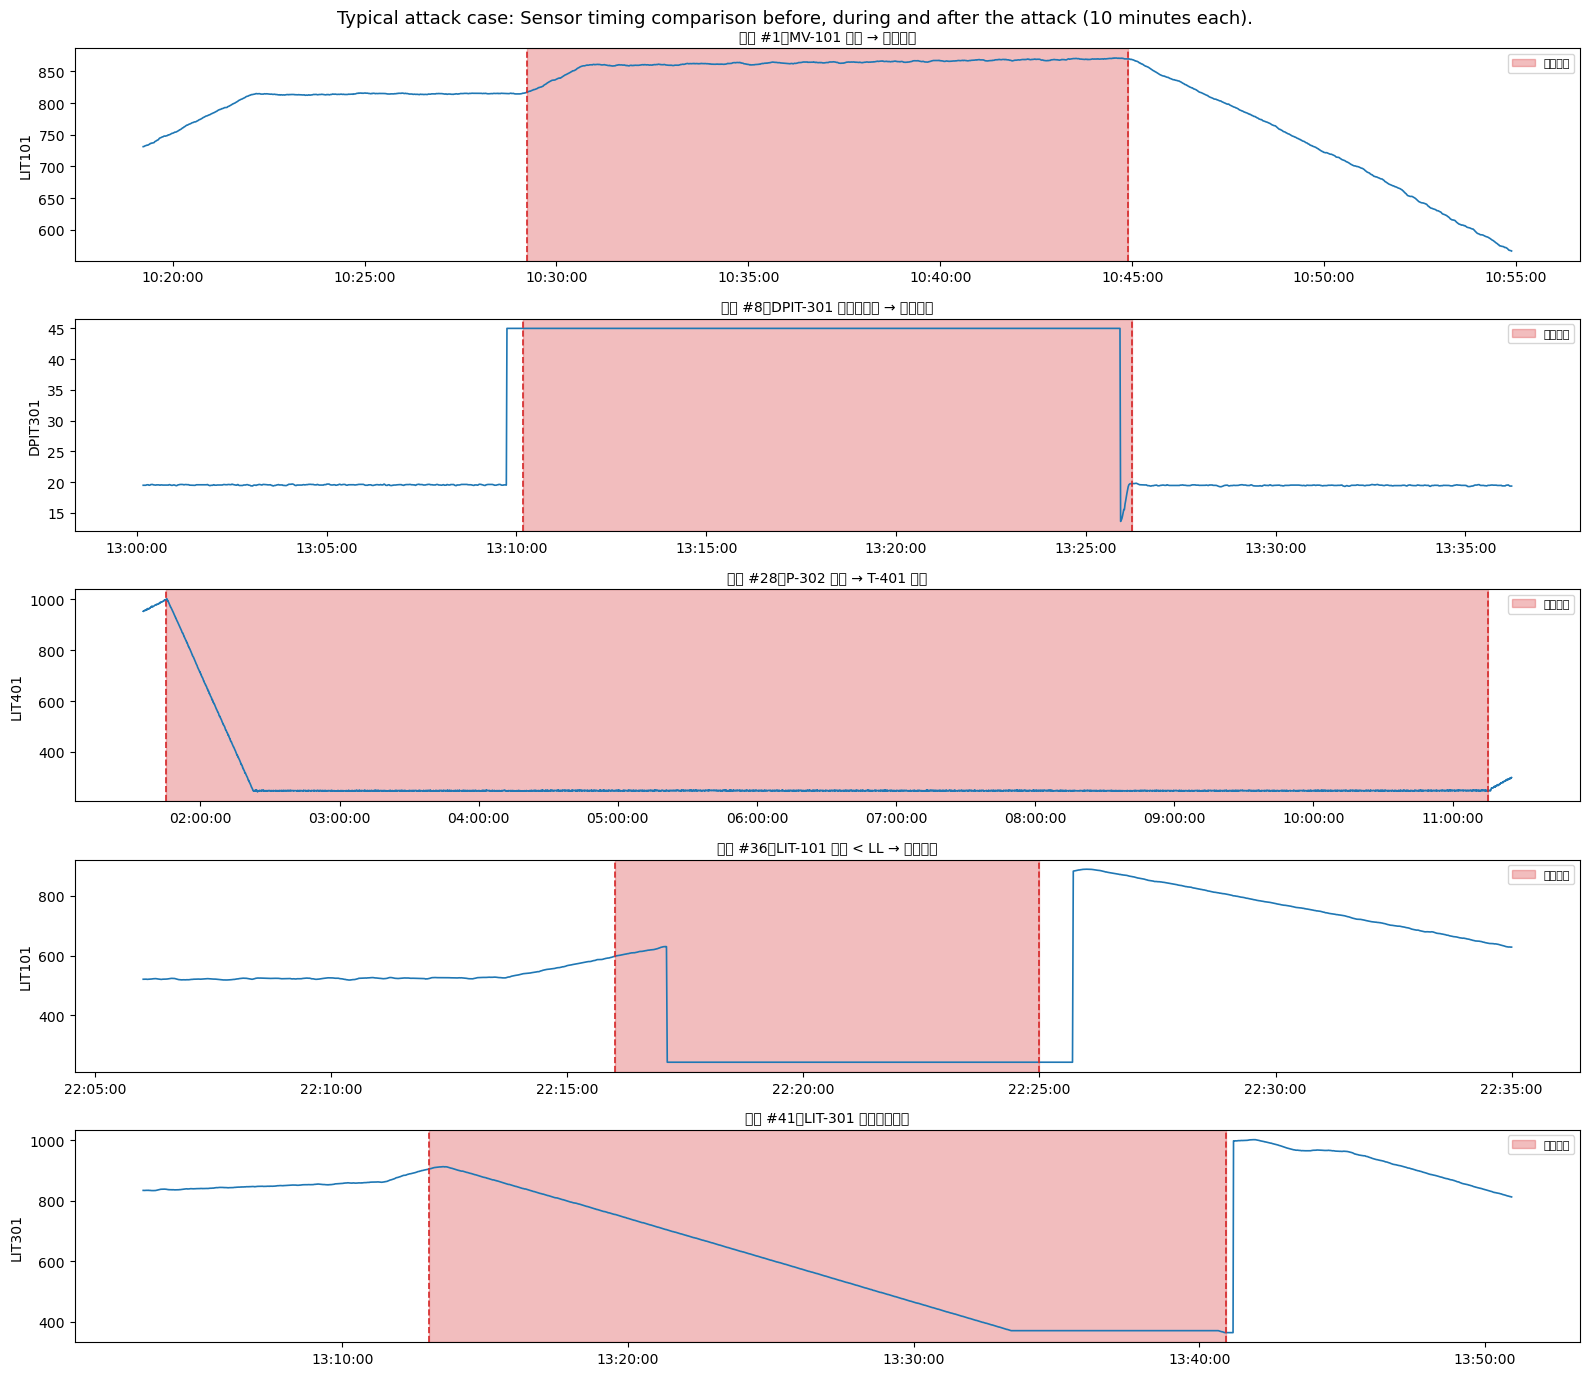

In [ ]:
# 10.4 時序對比：5 個典型攻擊的攻擊前/中/後感測器變化
typical_attacks = [
    (1,  'LIT101', 'Attack1: MV-101 開啟 → 水箱溢出'),
    (8,  'DPIT301','Attack8: DPIT-301 感測器欺騙 → 逆洗程序'),
    (28, 'LIT401', 'Attack28: P-302 關閉 → T-401 斷水'),
    (36, 'LIT101', 'Attack36: LIT-101 欺騙 < LL → 水箱溢出'),
    (41, 'LIT301', 'Attack41: LIT-301 緩慢遞減欺騙'),
]

fig, axes = plt.subplots(len(typical_attacks), 1, figsize=(16, 14), sharex=False)

for ax, (atk_id, sensor, title) in zip(axes, typical_attacks):
    label_str = f'Attack{atk_id}'
    sub = df_attack[df_attack['Detailed_Label'] == label_str]
    if sub.empty:
        ax.set_visible(False)
        continue

    t_start = sub['Timestamp'].min()
    t_end   = sub['Timestamp'].max()
    window_start = t_start - pd.Timedelta(minutes=10)
    window_end   = t_end   + pd.Timedelta(minutes=10)

    context = df_attack[(df_attack['Timestamp'] >= window_start) &
                         (df_attack['Timestamp'] <= window_end)]

    ax.plot(context['Timestamp'], context[sensor], lw=1.2, color='#1f77b4')
    ax.axvspan(t_start, t_end, alpha=0.3, color='#d62728', label='攻擊視窗')
    ax.axvline(t_start, color='#d62728', ls='--', lw=1.2)
    ax.axvline(t_end,   color='#d62728', ls='--', lw=1.2)
    ax.set_ylabel(sensor)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M:%S'))

plt.suptitle('Typical attack case: Sensor timing comparison before, during and after the attack (10 minutes each).', fontsize=13)
plt.tight_layout()
plt.show()